# How does the error improve with the number of models?
----

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from get_model_probabilities import *
from add_shear_to_data import get_model_names
import scienceplots
plt.style.use(["science","grid"])

DEFAULT ZS 2.28808070104492
Source redshift:2.2884950162268827


In [4]:
def get_all_model_estimates( 
    data, all_models,
):
    probabilities_filt = []
    with torch.no_grad():

        for imodel in tqdm(all_models):
            outputs_dict = imodel([torch.tensor(data,dtype=torch.float32)])
            #if torch.all(torch.abs(outputs_dict['classification'][:,0] - outputs_dict['classification'][0,0])  < 0.01):
            #   continue
            probabilities_filt.append(torch.softmax( outputs_dict['classification'], dim=1 )) 
    return torch.stack( probabilities_filt).detach().numpy()

In [5]:
args.log_mass_cut = 15
args.source_domain = 'darkskies_obs'
args.target_domain = 'bahamas_obs'
args.apply_intrinsic_ell = 1.
args.verbose = False

dataloaders = prepare_dataloaders(args)
ifilter='concat'

In [227]:
estimates = []
datasets = ['darkskies_cdm.pkl']
for dataset in datasets:
    meta, data = pkl.load(open(f"../data/100/obs/concat/{dataset}","rb"))
    all_data = []
    for i in range(data.shape[0]):
        this_data = dataloaders['source_val'][0].dataset.dataset.transform(torch.tensor(data[int(i),:2], dtype=torch.float32))

        this_data -= torch.min(this_data)
        this_data /= torch.max(this_data)

        all_data.append(this_data)

    forward_modelled = np.stack(all_data)

    all_models, seed_index = get_model_names(model='tweakedalign_best', 
                                                  load_model_args=args,
                                                 )
    estimates.append( get_all_model_estimates( 
        forward_modelled, all_models )
                    )
pkl.dump(estimates,open("pickles/how_correlated.pkl","wb"))

100%|███████████████████████████████████████████████████████████████████████████████████| 30/30 [02:19<00:00,  4.63s/it]


Text(0, 0.5, 'True Error / Standard Deviation')

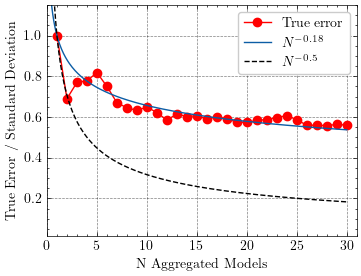

In [35]:
estimates = pkl.load(open("pickles/how_correlated.pkl","rb"))

fig, ax = plt.subplots(1,1, figsize=(4,3))
all_models, seed_index = get_model_names(model='tweakedalign_best', include_str='nob1' )
test_nmodels = range(1,len(all_models)+1)[::-1]
plot_models = np.linspace(0,30,310)
colors = [
    'r','b','g','c'
]

for iex, est in enumerate(estimates):
    means_fid = np.mean(est)
    #est = np.random.normal( means_fid, 0.01, est.shape)
    true_variance = []
    standard_err = []
    sigma = []
    for i in test_nmodels:

        means = np.mean(
            est[:i,:,1]-means_fid, axis=0
        )

        true_variance.append( np.std( means ))
        standard_err.append( np.std( est[:i,:,1] ) )

    error_scaling = np.array(true_variance) /np.array(standard_err) 

    ax.plot( test_nmodels, error_scaling, 'o-', label='True error', color=colors[iex] )
    #ax.plot( test_nmodels, standard_err, 'k:', label='Standard Error')

    
    def fit_sqrt( x, a, b ):
            return x**b


    popt, pcov = curve_fit(
                    fit_sqrt,
                    test_nmodels,
                    error_scaling,
                    )    

    ax.plot( plot_models, fit_sqrt(plot_models,*popt), '-', 
            label=f"$N^{{{popt[1]:0.2f}}}$")

    rescale_standard_err = popt[0]/np.sqrt(plot_models)
    
    ax.plot( plot_models, rescale_standard_err, 'k--', label='${N^{-0.5}}$')
        
ax.set_xlim(0,31)
ax.set_ylim(0.015,1.15) 
ax.legend()
ax.set_xlabel("N Aggregated Models")
ax.set_ylabel("True Error / Standard Deviation")


In [ ]:
30**-0.,